In [1]:
import sys
from pathlib import Path
import os 
import time
import glob
import itertools
import matplotlib.pyplot as plt
import pandas as pd
import random
PROJECT_ROOT = Path.cwd().parents[0]   # adjust if needed
sys.path.append(str(PROJECT_ROOT))
from src.jdr import jdr, jdr_parallel
from src.JDRKMedoids import JDRKMedoids
from astropy.timeseries import LombScargle
import pandas as pd
import numpy as np



In [2]:
PROJECT_ROOT

PosixPath('/home/franciscoperez/Documents/GitHub/JDR-Python')

In [3]:

from sklearn.datasets import fetch_openml
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA


In [4]:
#df_results = pd.DataFrame(results, columns=['file1', 'file2', 'jdr', 'time'])

In [5]:
# 1. Load MNIST
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

# 2. Scale pixels to [0, 1]
X = X / 255.0

# 3. Take a manageable subset
rng = np.random.default_rng(42)
n_samples = 30
idx = rng.choice(len(X), size=n_samples, replace=False)

X_sub = X[idx]
y_sub = y[idx]


# 4. Dimensionality reduction with PCA
n_components = 20
pca = PCA(n_components=n_components, random_state=42)
X_sub_pca = pca.fit_transform(X_sub)

print("Reduced shape:", X_sub_pca.shape)
print("Explained variance ratio sum:", pca.explained_variance_ratio_.sum())

# 5. Pairwise Euclidean distance in reduced space
D = pairwise_distances(X_sub_pca, metric="euclidean")
print("Distance matrix shape:", D.shape)

Reduced shape: (30, 20)
Explained variance ratio sum: 0.9309302242946252
Distance matrix shape: (30, 30)


In [6]:
# Fit clustering
model = JDRKMedoids(
    n_clusters=10,
    max_iter=100,
    random_state=42,
    verbose=True
)

In [7]:
labels = model.fit_predict(D)

Initial medoids: [20, 3, 0, 23, 8, 7, 24, 4, 28, 17]
True [20, 3, 0, 23, 29, 7, 13, 4, 28, 16]
Iteration 1: medoids = [20, 3, 0, 23, 29, 7, 13, 4, 28, 16]
Iteration 2: medoids = [20, 3, 0, 23, 29, 7, 13, 4, 28, 16]


In [8]:
y

array([5, 0, 4, ..., 4, 5, 6])

In [9]:

print("Medoid indices:", model.medoids_)
print("Clusters:", model.clusters_)
print("Inertia:", model.inertia_)

k = 0
for i in model.medoids_: 
    k = k + 1
    print('cluster: ', str(k), ' value: ', str(y[i]))

k = 0
for cluster_list in model.clusters_: 
    k = k + 1
    print('cluster: ', str(k))
    for objetc in cluster_list: 
        print(str(y[objetc]))

Medoid indices: [20, 3, 0, 23, 29, 7, 13, 4, 28, 16]
Clusters: [[9, 14, 19, 20], [3, 21, 25, 26], [0], [23], [8, 15, 29], [7, 12], [5, 13, 24], [4, 6, 11, 18], [1, 10, 22, 27, 28], [2, 16, 17]]
Inertia: 139.44362074344366
cluster:  1  value:  4
cluster:  2  value:  1
cluster:  3  value:  5
cluster:  4  value:  1
cluster:  5  value:  7
cluster:  6  value:  3
cluster:  7  value:  6
cluster:  8  value:  9
cluster:  9  value:  2
cluster:  10  value:  2
cluster:  1
4
1
9
4
cluster:  2
1
0
2
4
cluster:  3
5
cluster:  4
1
cluster:  5
1
7
7
cluster:  6
3
3
cluster:  7
2
6
1
cluster:  8
9
1
5
6
cluster:  9
0
3
9
3
2
cluster:  10
4
2
8


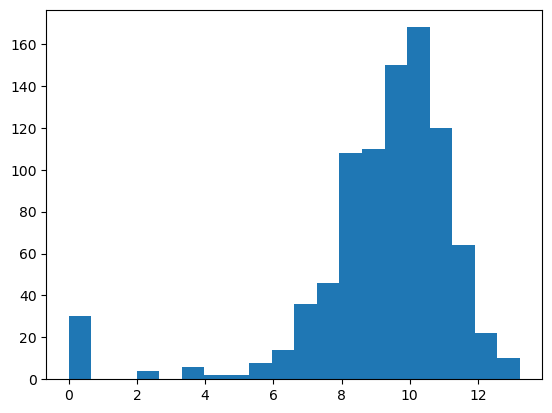

In [10]:
plt.hist(D.reshape(-1), bins=20)
plt.show()

In [11]:
type(labels)

numpy.ndarray

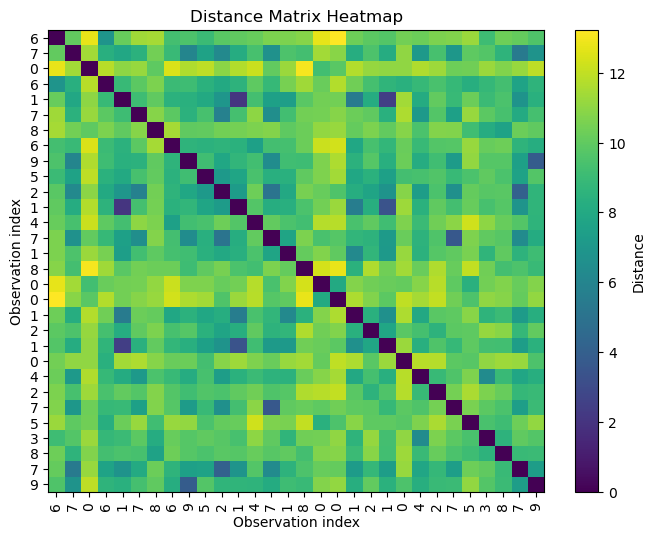

In [12]:
labels = y_sub.tolist()

plt.figure(figsize=(8, 6))
im = plt.imshow(D, aspect="auto")
plt.colorbar(im, label="Distance")
plt.title("Distance Matrix Heatmap")
plt.xlabel("Observation index")
plt.ylabel("Observation index")

plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)

plt.show()